In [8]:
#Muhammad Hashmi 24i-2037 Ds-5a

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("Sample - Superstore.csv",encoding="cp1252")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


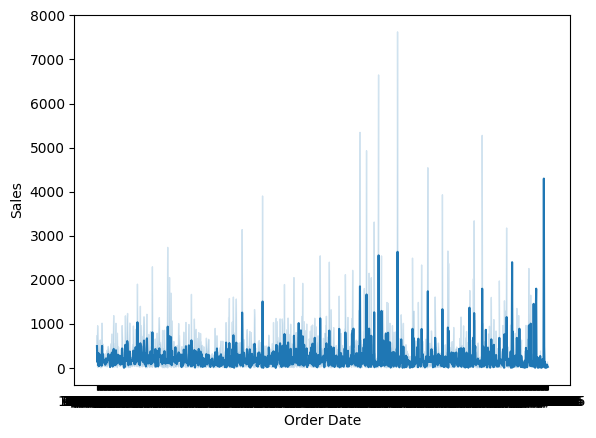

In [9]:
# task 1

#linechart
line_chart = sns.lineplot(data=df, x="Order Date", y="Sales")

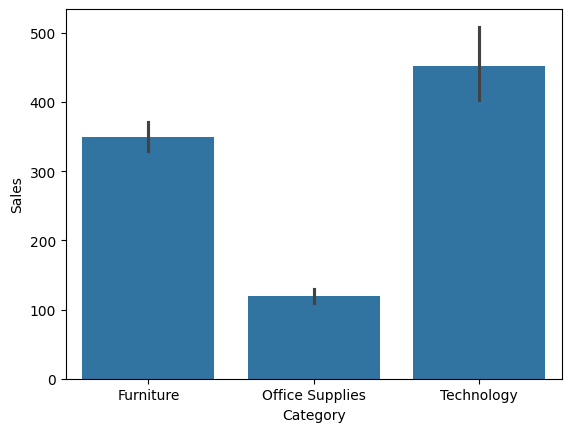

In [10]:
#bar chart
bar_chart = sns.barplot(data=df, x="Category", y="Sales")


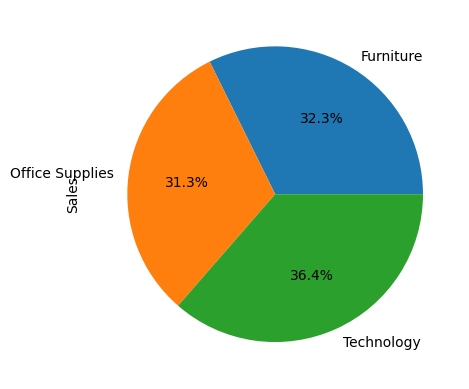

In [ ]:
#pie chart
pie_chart = df.groupby('Category')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%')
# pie chart is the best in my opinion because it shows the proportion of sales for each category in a clear way with exact figures which we can use for analysis and comparison

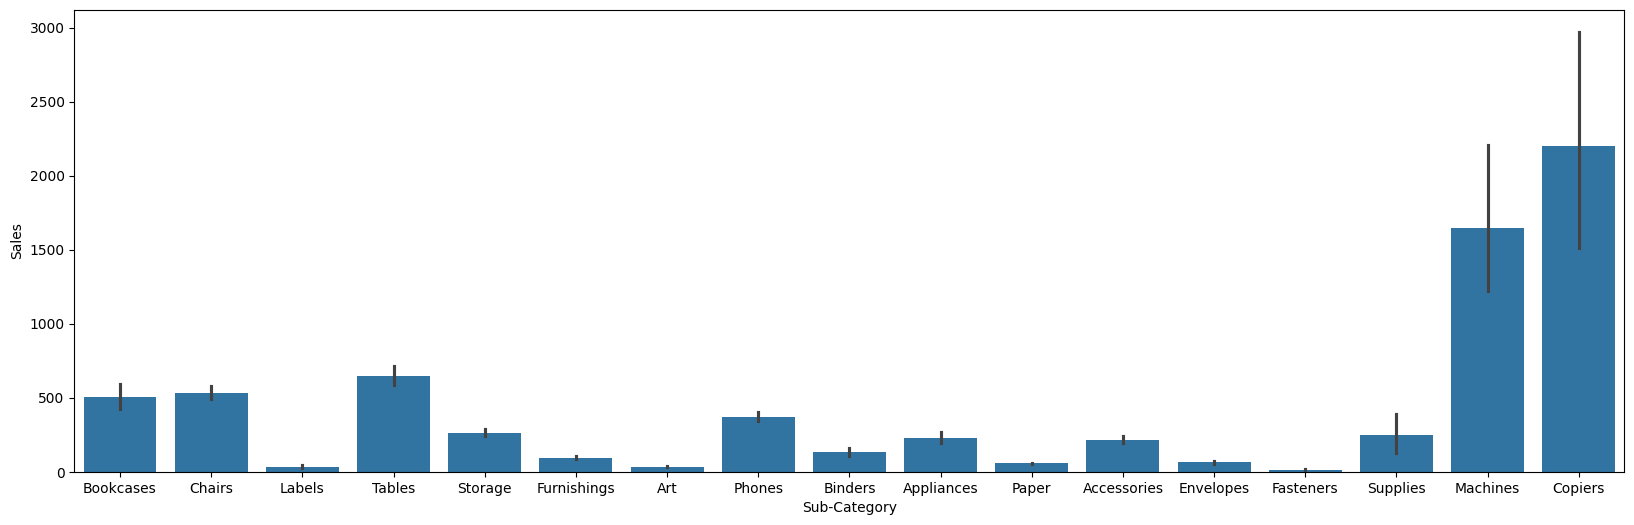

In [ ]:
# Task 2
# chosing bar chart
plt.figure(figsize=(20, 6))
bar_chart = sns.barplot(data=df, x="Sub-Category", y="Sales")
# this way i can see and combare the sales of each sub category in a clear way and also we can see which sub category is performing better than others

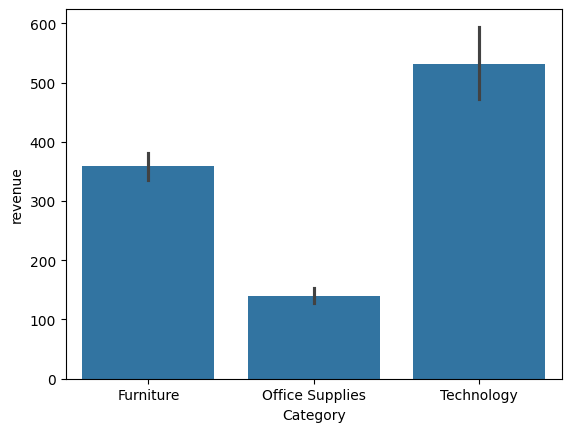

In [ ]:
# choosing bar chart for revenue
df['revenue'] = df['Sales'] + df['Profit']
bar_chart = sns.barplot(data=df, x="Category", y="revenue")

# This is choosen so i can compare revene of each category easily.

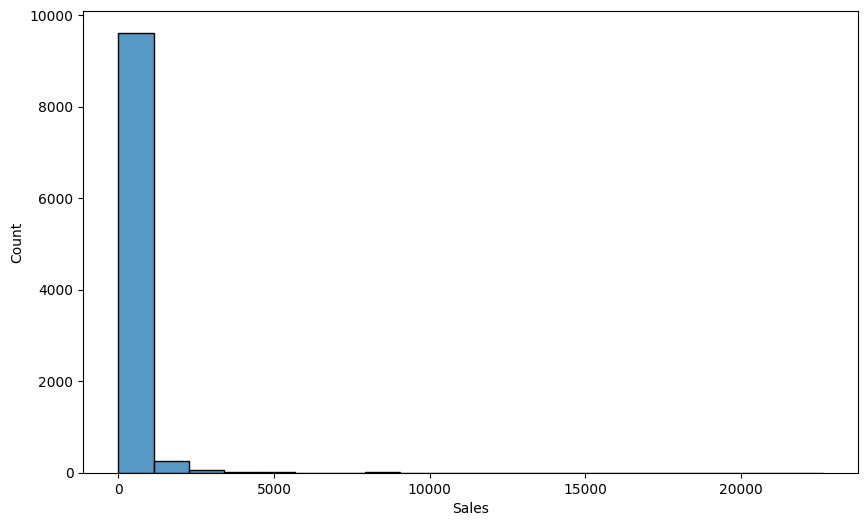

In [24]:
#histogram for checking spread of sales
plt.figure(figsize=(10, 6))
histogram = sns.histplot(data=df, x="Sales",bins=20)

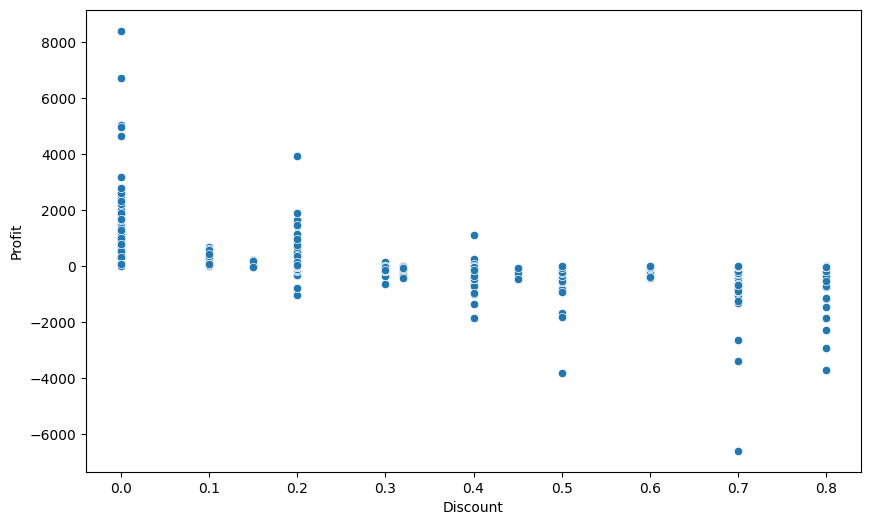

In [25]:
#relationship between discount level and profit
plt.figure(figsize=(10, 6))
scatter_plot = sns.scatterplot(data=df, x="Discount", y="Profit")

C:\Users\Lab\AppData\Local\Temp\ipykernel_13412\1648302940.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_chart = sns.barplot(data=df, x="Region", y="Sales", palette="Set2")


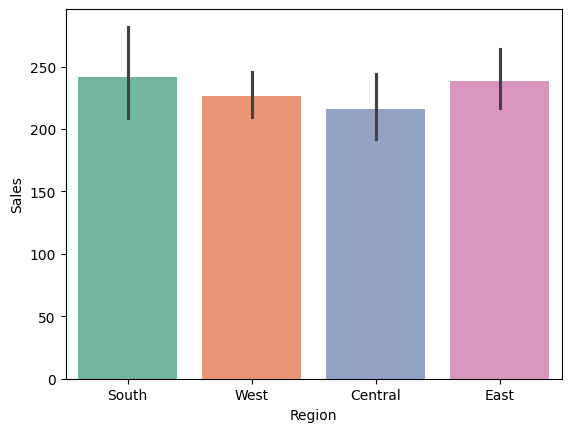

In [ ]:
# Task 3
# chosing bar chart for sales by region

bar_chart = sns.barplot(data=df, x="Region", y="Sales", palette="Set2")



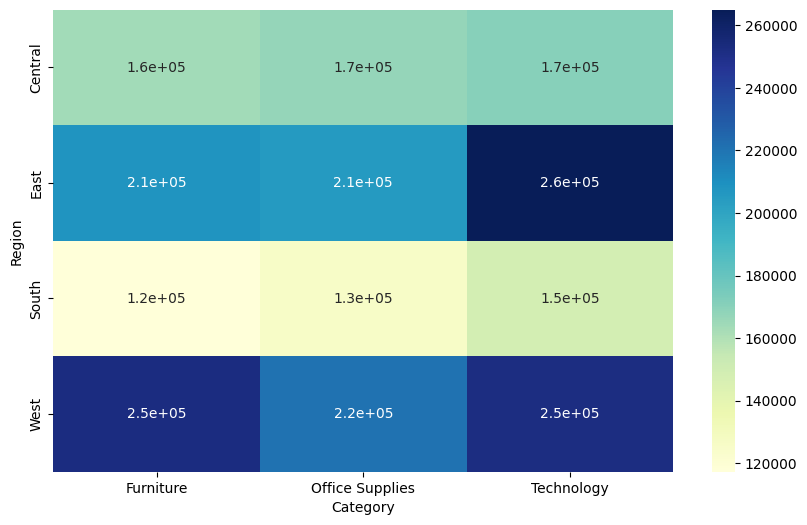

In [30]:

heatmap_data = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')
plt.figure(figsize=(10, 6))
heatmap = sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True)

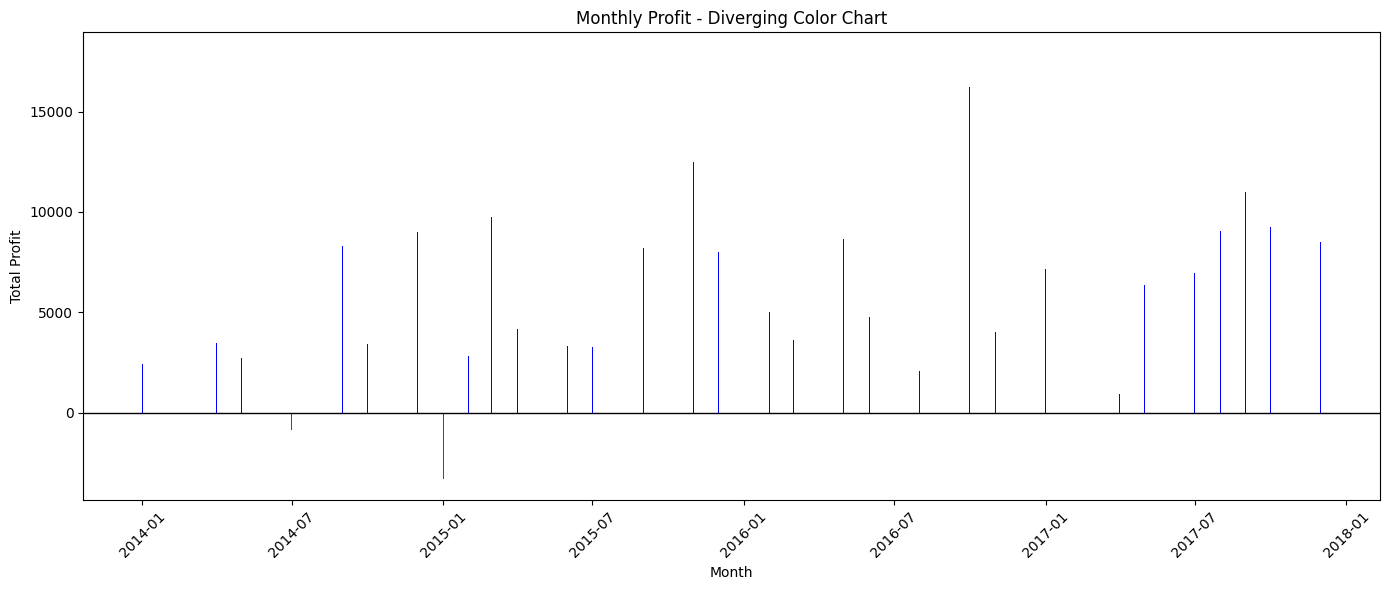

In [39]:
# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Calculate total profit by month
monthly_profit = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Profit"]
    .sum()
    .reset_index()
)

monthly_profit["Order Date"] = monthly_profit["Order Date"].dt.to_timestamp()

# Diverging colors:
# Red = negative profit
# Blue = positive profit
colors = ["red" if x < 0 else "blue" for x in monthly_profit["Profit"]]

# Create chart
plt.figure(figsize=(14, 6))
plt.bar(monthly_profit["Order Date"], monthly_profit["Profit"], color=colors)

# Zero reference line
plt.axhline(0, color="black", linewidth=1)

plt.title("Monthly Profit - Diverging Color Chart")
plt.xlabel("Month")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Task 4 
#a)
import numpy as np

def luminance(rgb):
    rgb = np.array(rgb) / 255
    rgb = np.where(rgb <= 0.03928,
                   rgb / 12.92,
                   ((rgb + 0.055) / 1.055) ** 2.4)
    return 0.2126*rgb[0] + 0.7152*rgb[1] + 0.0722*rgb[2]

def contrast_ratio(c1, c2):
    L1, L2 = luminance(c1), luminance(c2)
    return (max(L1, L2) + 0.05) / (min(L1, L2) + 0.05)

# Test colors from Task 3
colors = {
    "Red": (255, 0, 0),
    "Green": (0, 128, 0),
    "Blue": (0, 0, 255),
    "Purple": (128, 0, 128)
}

for name, rgb in colors.items():
    ratio = contrast_ratio(rgb, (255, 255, 255))
    print(name, f"{ratio:.2f}:1",
          "PASS" if ratio >= 4.5 else "FAIL")

Red 4.00:1 FAIL
Green 5.14:1 PASS
Blue 8.59:1 PASS
Purple 9.42:1 PASS


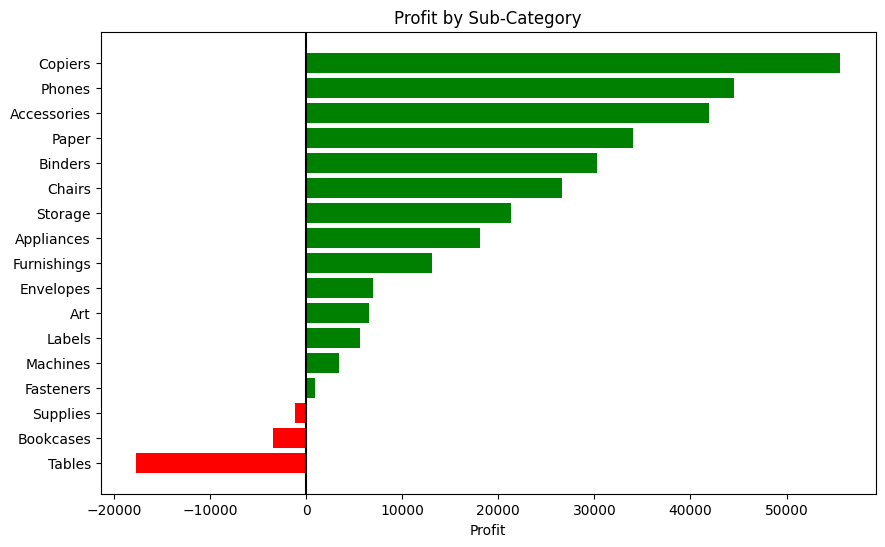

In [41]:
#b)
profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()

colors = ["red" if x < 0 else "green" for x in profit]

plt.figure(figsize=(10,6))
plt.barh(profit.index, profit.values, color=colors)
plt.axvline(0, color="black")
plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.show()

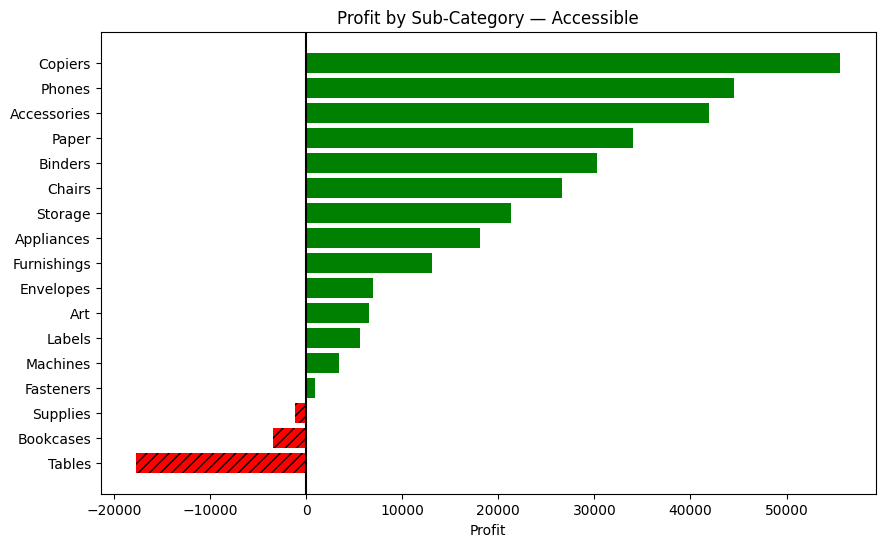

In [ ]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    profit.index,
    profit.values,
    color=["red" if x < 0 else "green" for x in profit]
)

for bar, value in zip(bars, profit.values):
    if value < 0:
        bar.set_hatch("///")

plt.axvline(0, color="black")
plt.title("Profit by Sub-Category — Accessible")
plt.xlabel("Profit")
plt.show()

# red hatched bars showing losses and green bars showing gains this is easy for people with color blindness to figure out as it is not only based on color but also on pattern.

C:\Users\Lab\AppData\Local\Temp\ipykernel_13412\447720992.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barchart = sns.barplot(data=df, x="Region", y="Sales", palette="Set2")


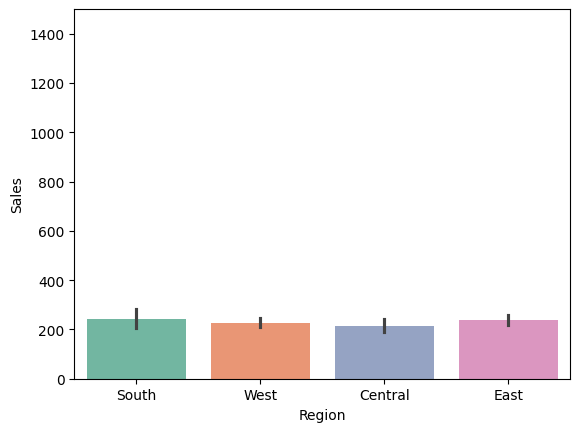

In [46]:
# Task 5
barchart = sns.barplot(data=df, x="Region", y="Sales", palette="Set2")
truncated_y_axis = plt.ylim(0, 1500)

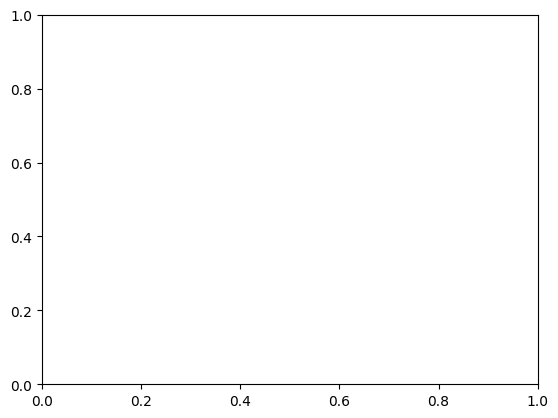

In [ ]:

datewindow = df[(df["Order Date"] >= "2019-01-01") & (df["Order Date"] <= "2019-12-31")]
bar_chart = sns.barplot(data=datewindow, x="Region", y="Sales", palette="Set2")



C:\Users\Lab\AppData\Local\Temp\ipykernel_13412\2981798734.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barchart = sns.barplot(data=df, x="Region", y="Sales", palette="Set2")


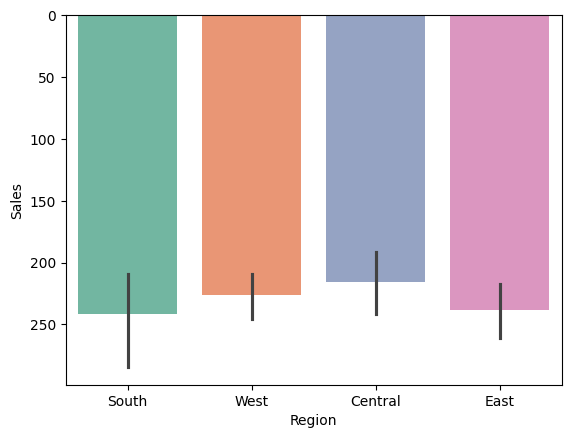

In [49]:
#An inverted y-axis on the monthly profit or sales line
inverted_y_axis = plt.gca().invert_yaxis()
barchart = sns.barplot(data=df, x="Region", y="Sales", palette="Set2")

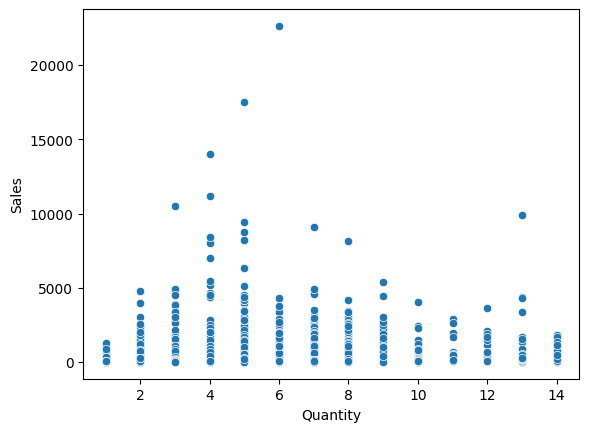

In [50]:
# task 6
# is low quantity affecting sales?
scatter_plot = sns.scatterplot(data=df, x="Quantity", y="Sales")

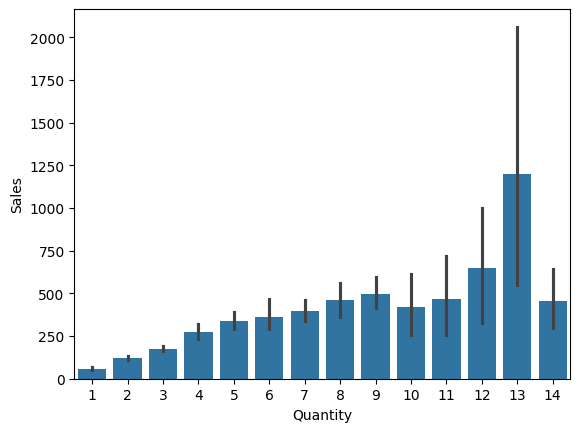

In [ ]:
# are low sales due to high quanitiy?
barchart = sns.barplot(data=df, x="Quantity", y="Sales")

# i used wrong questiong later and checked but it is wrong as high quantity is not causing low sales but low quantity is causing low sales as we can see in the scatter plot that low quantity is causing low sales and high quantity is causing high sales.